作业 1
 丁平尖
 2026 年 4 月 13 日

1 注意事项
1. 编程题需要打印相应的输出；
2. 将 ipynb 文件提交至 github 上，命名为：HW01-学号-姓名.ipynb

2 概述、线性代数和 NDArray
## 2.1 理论计算题

已知向量 $a = [2, -1, 3]^\top$，$b = [1, 4, -2]^\top$，矩阵

$$
A = \begin{bmatrix}
-1 & 0 & 2 \\
1 & 3 & 1
\end{bmatrix},\quad
B = \begin{bmatrix}
2 & 1 \\
0 & 3 \\
2 & -1
\end{bmatrix}
$$

计算：

1. 向量点积 $a \cdot b$；
2. 矩阵乘法 $A \times B$（结果矩阵的形状？）；
3. 向量 $a$ 的 Frobenius 范数。

### 解答

1. $a \cdot b = 2\times1 + (-1)\times4 + 3\times(-2) = -8$
2. $A$ 的形状为 $2\times3$，$B$ 的形状为 $3\times2$，所以 $A\times B$ 的结果形状为 $2\times2$

   $$
   A B =
   \begin{bmatrix}
   -1 & 0 & 2 \\
   1 & 3 & 1
   \end{bmatrix}
   \begin{bmatrix}
   2 & 1 \\
   0 & 3 \\
   2 & -1
   \end{bmatrix}
   =
   \begin{bmatrix}
   2 & -3 \\
   4 & 9
   \end{bmatrix}
   $$

3. 向量 $a$ 的 Frobenius 范数（即欧几里得范数）为

   $$
   \|a\|_F = \sqrt{2^2 + (-1)^2 + 3^2} = \sqrt{14}
   $$

2.2 编程题
使用 NumPy（或 MXNet / PyTorch/TensorFlow）完成以下任务：
1. 创建一个形状为 3 × 4 的随机矩阵 X，元素服从标准正态分布。
2. 创建一个形状为 4 × 2 的全 1 矩阵 Y 。
3. 计算矩阵乘法 Z = X × Y 。
4. 输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第 2 行所有元素。
5. 计算 Z 的 Frobenius 范数。

In [2]:
import warnings
import torch
warnings.filterwarnings(
    'ignore',
    message='A module that was compiled using NumPy 1.x cannot be run in NumPy 2.2.5 as it may crash.*',
    category=UserWarning,
)
warnings.filterwarnings(
    'ignore',
    message='Failed to initialize NumPy: _ARRAY_API not found.*',
    category=UserWarning,
)



# 1、创建 3x4 标准正态分布随机矩阵 X
torch.manual_seed(42)  
X = torch.randn(3, 4)
print('X =\n', X)

# 2、创建 4x2 全 1 矩阵 Y
Y = torch.ones(4, 2)
print('Y =\n', Y)

# 3、计算矩阵乘法 Z = X @ Y
Z = X @ Y
print('Z =\n', Z)

# 4、输出指定元素与第 2 行元素
cross_element = Z[0, 1]  # 第一行第二列（索引从 0 开始）
second_row = Z[1, :]     # 第 2 行所有元素
print('\nZ 的第一行第二列元素 =', cross_element.item())
print('Z 的第 2 行所有元素 =', second_row)

# 5、计算 Z 的 Frobenius 范数
fro_norm = torch.norm(Z, p='fro')
print('Z 的 Frobenius 范数 =', fro_norm.item())

X =
 tensor([[ 0.3367,  0.1288,  0.2345,  0.2303],
        [-1.1229, -0.1863,  2.2082, -0.6380],
        [ 0.4617,  0.2674,  0.5349,  0.8094]])
Y =
 tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]])
Z =
 tensor([[0.9303, 0.9303],
        [0.2610, 0.2610],
        [2.0733, 2.0733]])

Z 的第一行第二列元素 = 0.9302951693534851
Z 的第 2 行所有元素 = tensor([0.2610, 0.2610])
Z 的 Frobenius 范数 = 3.2348194122314453


3 文档 2：概率与统计

3.1 理论计算题
某疾病在人群中的患病率为 0.1%。现有一种检测方法：
• 若患病，检测呈阳性的概率为 99%（灵敏度）；
• 若未患病，检测呈阳性的概率为 2%（假阳性率）。
一个人检测结果为阳性，求他真正患病的概率（使用贝叶斯公式）。

### 解答

设
$$
P(D)=0.001,\quad P(\overline{D})=0.999
$$
其中 $D$ 表示“患病”，$\overline{D}$ 表示“未患病”。已知
$$
P(+\mid D)=0.99,\quad P(+\mid \overline{D})=0.02
$$
根据贝叶斯公式：
$$
P(D\mid +)=\frac{P(+\mid D)P(D)}{P(+\mid D)P(D)+P(+\mid \overline{D})P(\overline{D})}
$$
代入数值：
$$
P(D\mid +)=\frac{0.99\times 0.001}{0.99\times 0.001+0.02\times 0.999}
=\frac{0.00099}{0.02097}
\approx 0.0472
$$

**结论：** 检测结果为阳性的人，真正患病的概率约为 **4.72%**。

3.2 编程题
用 Python 模拟中心极限定理：
1. 生成 n = 10000 个服从均匀分布 U(0, 1) 的随机变量，重复 m = 1000
次，每次计算这 n 个变量的均值。
2. 绘制这 1000 个均值的直方图，并叠加理论正态分布的概率密度曲线。
3. 计算这些均值的实际方差。

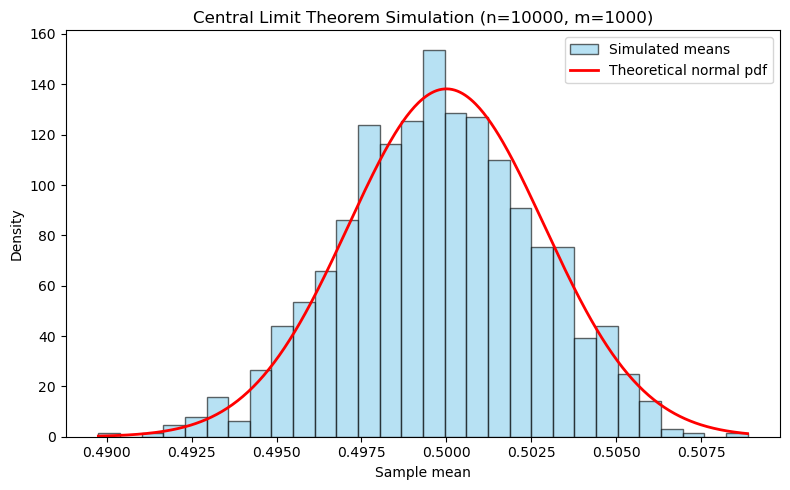

实际方差: 0.0000081677
理论方差: 0.0000083333


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 参数
n = 10000   # 每次样本量
m = 1000    # 重复次数

# 1、生成均匀分布样本并计算每次均值
samples = np.random.uniform(0, 1, size=(m, n))
means = samples.mean(axis=1)

# 2、绘制均值直方图 + 理论正态分布密度曲线
mu = 0.5
sigma = np.sqrt(1 / (12 * n))   # U(0,1) 的均值标准差（样本均值的理论标准差）

x = np.linspace(means.min(), means.max(), 500)
pdf = 1 / (np.sqrt(2 * np.pi) * sigma) * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

plt.figure(figsize=(8, 5))
plt.hist(means, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Simulated means')
plt.plot(x, pdf, 'r-', lw=2, label='Theoretical normal pdf')
plt.title(f'Central Limit Theorem Simulation (n={n}, m={m})')
plt.xlabel('Sample mean')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

# 3、计算实际方差
actual_var = np.var(means, ddof=1)           # 样本方差
theoretical_var = 1 / (12 * n)               # 理论方差

print(f"实际方差: {actual_var:.10f}")
print(f"理论方差: {theoretical_var:.10f}")

4 文档 3：导数、反向传播和复杂度
4.1 理论计算题
给定函数 z = (w1x1 + w2x2 − y)
2，其中 x1 = 2, x2 = 1, y = 3 为常数，
w1, w2 为变量。
1. 分别计算 ∂w
∂z
1 和 ∂w
∂z
2 的表达式。
2. 若当前 w1 = 0.5, w2 = 1，计算梯度值。

### 解答

设
$$
 s = w_1 x_1 + w_2 x_2 - y
$$
则
$$
 z = s^2
$$
由链式法则可得
$$
\frac{\partial z}{\partial w_1} = 2s\frac{\partial s}{\partial w_1} = 2(w_1x_1+w_2x_2-y)x_1
$$
$$
\frac{\partial z}{\partial w_2} = 2s\frac{\partial s}{\partial w_2} = 2(w_1x_1+w_2x_2-y)x_2
$$

代入 $x_1=2, x_2=1, y=3$ 后，得到
$$
\frac{\partial z}{\partial w_1} = 4(2w_1+w_2-3)
$$
$$
\frac{\partial z}{\partial w_2} = 2(2w_1+w_2-3)
$$

当 $w_1=0.5, w_2=1$ 时，
$$
2w_1+w_2-3 = 2\times 0.5 + 1 - 3 = -1
$$
所以梯度为
$$
\frac{\partial z}{\partial w_1} = -4,\qquad \frac{\partial z}{\partial w_2} = -2
$$

**结论：** 当前参数下的梯度向量为
$$
\nabla z = (-4, -2)
$$

4.2 编程题
手动实现一个简单计算图的反向传播：
1. 定义前向计算：输入 x，经过 a = x · w1，b = a + w2，输出 L = b^2。
2. 给定 x = 2, w1 = 1.5, w2 = 0.5，计算前向结果。
3. 手动（按链式法则）计算损失 L 对 w1, w2 的梯度，并验证与自动微分
工具（如 torch.autograd）的结果是否一致。

In [7]:
import warnings
import torch
warnings.filterwarnings(
    'ignore',
    message='A module that was compiled using NumPy 1.x cannot be run in NumPy 2.2.5 as it may crash.*',
    category=UserWarning,
)
warnings.filterwarnings(
    'ignore',
    message='Failed to initialize NumPy: _ARRAY_API not found.*',
    category=UserWarning,
)


# 前向计算参数
x = 2.0
w1 = 1.5
w2 = 0.5

# 前向计算：a = x * w1, b = a + w2, L = b^2
a = x * w1
b = a + w2
L = b ** 2

print(f'前向结果: a = {a}, b = {b}, L = {L}')

# 手动链式法则
# dL/db = 2b, db/dw1 = x, db/dw2 = 1
dL_db = 2 * b
grad_w1_manual = dL_db * x
grad_w2_manual = dL_db * 1.0

print(f'手动梯度: dL/dw1 = {grad_w1_manual}, dL/dw2 = {grad_w2_manual}')

# 自动微分验证
x_t = torch.tensor(2.0)
w1_t = torch.tensor(1.5, requires_grad=True)
w2_t = torch.tensor(0.5, requires_grad=True)

a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2
L_t.backward()

print(f'autograd 梯度: dL/dw1 = {w1_t.grad.item()}, dL/dw2 = {w2_t.grad.item()}')
print('手动与自动微分结果一致:',
      abs(grad_w1_manual - w1_t.grad.item()) < 1e-12 and abs(grad_w2_manual - w2_t.grad.item()) < 1e-12)

前向结果: a = 3.0, b = 3.5, L = 12.25
手动梯度: dL/dw1 = 14.0, dL/dw2 = 7.0
autograd 梯度: dL/dw1 = 14.0, dL/dw2 = 7.0
手动与自动微分结果一致: True


5 文档 4：线性方法、基础优化和 softmax 回归

5.1 理论计算题
考虑线性回归模型 y = wx + b，使用均方误差损失
L =
n
1
n∑
i=1
(yi − (wxi + b))2

推导损失对 w 和 b 的偏导数表达式（用求和形式）。


### 解答

均方误差损失写为
$$
L(w,b)=\frac{1}{n}\sum_{i=1}^{n}\left(y_i-(wx_i+b)\right)^2
$$

记误差项
$$
e_i = y_i-(wx_i+b)
$$
则
$$
L=\frac{1}{n}\sum_{i=1}^{n} e_i^2
$$

对 $w$ 求偏导：
$$
\frac{\partial L}{\partial w}
=\frac{1}{n}\sum_{i=1}^{n}2e_i\frac{\partial e_i}{\partial w}
=\frac{1}{n}\sum_{i=1}^{n}2e_i(-x_i)
=-\frac{2}{n}\sum_{i=1}^{n}x_i\left(y_i-(wx_i+b)\right)
$$

对 $b$ 求偏导：
$$
\frac{\partial L}{\partial b}
=\frac{1}{n}\sum_{i=1}^{n}2e_i\frac{\partial e_i}{\partial b}
=\frac{1}{n}\sum_{i=1}^{n}2e_i(-1)
=-\frac{2}{n}\sum_{i=1}^{n}\left(y_i-(wx_i+b)\right)
$$

等价写法（把符号移到括号内）为
$$
\frac{\partial L}{\partial w}=\frac{2}{n}\sum_{i=1}^{n}\left((wx_i+b)-y_i\right)x_i,
\qquad
\frac{\partial L}{\partial b}=\frac{2}{n}\sum_{i=1}^{n}\left((wx_i+b)-y_i\right)
$$

5.2 编程题
从零实现 softmax 回归对手写数字（MNIST）进行分类：
1. 使用 sklearn.datasets.load_digits() 或自己加载 MNIST 子集。
2. 将图像展平为向量，对标签进行 one‑hot 编码。
3. 实现 softmax 函数、交叉熵损失函数。
4. 使用小批量随机梯度下降（批量大小 32，学习率 0.1）训练模型 50 个
epoch。
5. 输出测试集上的准确率

In [1]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# 1) 加载数据（8x8 手写数字）
digits = load_digits()
X = digits.data.astype(np.float64)      # 已展平为 (N, 64)
y = digits.target.astype(np.int64)

# 2) 归一化并 one-hot 编码
X = X / 16.0                            # 像素范围从 [0,16] 缩放到 [0,1]
num_classes = 10
Y = np.eye(num_classes)[y]              # (N, 10)

X_train, X_test, y_train, y_test, Y_train, Y_test = train_test_split(
    X, y, Y, test_size=0.2, random_state=42, stratify=y
)

# 3) 定义 softmax 和交叉熵损失
def softmax(logits):
    # 数值稳定：减去每行最大值
    shifted = logits - np.max(logits, axis=1, keepdims=True)
    exp_scores = np.exp(shifted)
    return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)


def cross_entropy(probs, y_onehot):
    eps = 1e-12
    probs = np.clip(probs, eps, 1.0)
    return -np.mean(np.sum(y_onehot * np.log(probs), axis=1))


# 4) Mini-batch SGD 训练 softmax 回归
rng = np.random.default_rng(42)
num_features = X_train.shape[1]
W = np.zeros((num_features, num_classes), dtype=np.float64)
b = np.zeros((1, num_classes), dtype=np.float64)

lr = 0.1
batch_size = 32
epochs = 50

n_train = X_train.shape[0]
num_batches = (n_train + batch_size - 1) // batch_size

for epoch in range(1, epochs + 1):
    indices = rng.permutation(n_train)
    X_train_shuf = X_train[indices]
    Y_train_shuf = Y_train[indices]

    for i in range(num_batches):
        start = i * batch_size
        end = min(start + batch_size, n_train)

        xb = X_train_shuf[start:end]
        yb = Y_train_shuf[start:end]

        logits = xb @ W + b
        probs = softmax(logits)

        # softmax + 交叉熵对 logits 的梯度
        grad_logits = (probs - yb) / xb.shape[0]
        grad_W = xb.T @ grad_logits
        grad_b = np.sum(grad_logits, axis=0, keepdims=True)

        W -= lr * grad_W
        b -= lr * grad_b

    if epoch % 10 == 0 or epoch == 1:
        train_probs = softmax(X_train @ W + b)
        train_loss = cross_entropy(train_probs, Y_train)
        print(f"Epoch {epoch:2d}/{epochs} - train loss: {train_loss:.4f}")

# 5) 测试集准确率
test_probs = softmax(X_test @ W + b)
test_pred = np.argmax(test_probs, axis=1)
test_acc = np.mean(test_pred == y_test)
print(f"Test accuracy: {test_acc:.4f}")

Epoch  1/50 - train loss: 1.6069
Epoch 10/50 - train loss: 0.4379
Epoch 20/50 - train loss: 0.2920
Epoch 30/50 - train loss: 0.2344
Epoch 40/50 - train loss: 0.2020
Epoch 50/50 - train loss: 0.1805
Test accuracy: 0.9528


6 文档 5：最大似然估计和逻辑回归
6.1 理论计算题
假设样本 x1, x2, . . . , xn 独立同分布于正态分布 N (µ, σ2
)。
1. 写出似然函数 L(µ, σ2
)。
2. 证明：µ 的最大似然估计为 µˆ = n
1 ∑n
i=1 xi。
3. 证明：σ
2 的最大似然估计为 σˆ
2 = n
1 ∑n
i=1(xi − µˆ)
2。


### 解答

设样本 $x_1,\dots,x_n$ 独立同分布于 $\mathcal{N}(\mu,\sigma^2)$，其密度为
$$
f(x_i\mid \mu,\sigma^2)=\frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)
$$

1. 似然函数
$$
L(\mu,\sigma^2)=\prod_{i=1}^n f(x_i\mid\mu,\sigma^2)
=(2\pi\sigma^2)^{-\frac{n}{2}}\exp\left(-\frac{1}{2\sigma^2}\sum_{i=1}^n(x_i-\mu)^2\right)
$$

取对数似然：
$$
\ell(\mu,\sigma^2)=\log L=-\frac{n}{2}\log(2\pi)-\frac{n}{2}\log\sigma^2-\frac{1}{2\sigma^2}\sum_{i=1}^n(x_i-\mu)^2
$$

2. 证明 $\hat\mu=\frac{1}{n}\sum_{i=1}^n x_i$

对 $\mu$ 求偏导：
$$
\frac{\partial \ell}{\partial \mu}
=-\frac{1}{2\sigma^2}\cdot 2\sum_{i=1}^n(\mu-x_i)
=\frac{1}{\sigma^2}\sum_{i=1}^n(x_i-\mu)
$$
令其为 0：
$$
\sum_{i=1}^n(x_i-\mu)=0
\Rightarrow n\mu=\sum_{i=1}^n x_i
\Rightarrow \hat\mu=\frac{1}{n}\sum_{i=1}^n x_i
$$

3. 证明 $\hat\sigma^2=\frac{1}{n}\sum_{i=1}^n(x_i-\hat\mu)^2$

对 $\sigma^2$ 求偏导：
$$
\frac{\partial \ell}{\partial \sigma^2}
=-\frac{n}{2\sigma^2}+\frac{1}{2(\sigma^2)^2}\sum_{i=1}^n(x_i-\mu)^2
$$
令其为 0 并化简：
$$
-\frac{n}{2\sigma^2}+\frac{1}{2(\sigma^2)^2}\sum_{i=1}^n(x_i-\mu)^2=0
\Rightarrow n\sigma^2=\sum_{i=1}^n(x_i-\mu)^2
$$
因此
$$
\hat\sigma^2=\frac{1}{n}\sum_{i=1}^n(x_i-\hat\mu)^2
$$

**结论：** 正态分布参数的极大似然估计为
$$
\hat\mu=\bar x,\qquad
\hat\sigma^2=\frac{1}{n}\sum_{i=1}^n(x_i-\bar x)^2
$$

6.2 编程题
实现二分类逻辑回归模型（不使用深度学习框架的高阶 API）：
1. 生成两类线性可分的数据：每类 200 个样本，特征维度为 2。
2. 定义 sigmoid 函数和二元交叉熵损失。
3. 使用梯度下降法（学习率 0.1，迭代 1000 次）学习参数 w, b。
4. 绘制决策边界，并计算模型在测试集（新生成 100 个样本）上的分类
准确率。

Iter    1/1000, Loss: 0.6931
Iter  200/1000, Loss: 0.0319
Iter  400/1000, Loss: 0.0258
Iter  600/1000, Loss: 0.0235
Iter  800/1000, Loss: 0.0222
Iter 1000/1000, Loss: 0.0214


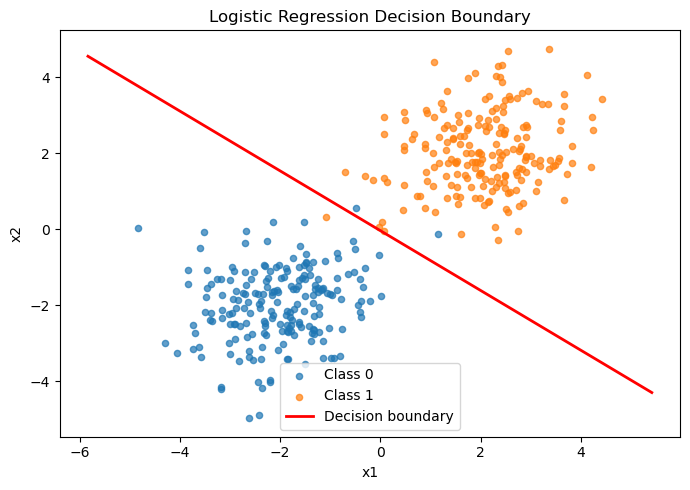

Test accuracy: 1.0000


In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# 1) 生成两类线性可分数据（每类 200 个样本，2 维特征）
n_per_class = 200
mean0 = np.array([-2.0, -2.0])
mean1 = np.array([2.0, 2.0])
cov = np.array([[1.0, 0.2], [0.2, 1.0]])

X0 = np.random.multivariate_normal(mean0, cov, size=n_per_class)
X1 = np.random.multivariate_normal(mean1, cov, size=n_per_class)

X_train = np.vstack([X0, X1])
y_train = np.hstack([np.zeros(n_per_class), np.ones(n_per_class)])

# 2) 定义 sigmoid 与二元交叉熵
def sigmoid(z):
    z = np.clip(z, -50, 50)
    return 1.0 / (1.0 + np.exp(-z))


def bce_loss(y_true, y_prob):
    eps = 1e-12
    y_prob = np.clip(y_prob, eps, 1.0 - eps)
    return -np.mean(y_true * np.log(y_prob) + (1.0 - y_true) * np.log(1.0 - y_prob))


# 3) 梯度下降训练参数 w, b
w = np.zeros(X_train.shape[1], dtype=np.float64)
b = 0.0

lr = 0.1
iters = 1000

for t in range(1, iters + 1):
    logits = X_train @ w + b
    probs = sigmoid(logits)

    error = probs - y_train
    grad_w = (X_train.T @ error) / X_train.shape[0]
    grad_b = np.mean(error)

    w -= lr * grad_w
    b -= lr * grad_b

    if t % 200 == 0 or t == 1:
        loss = bce_loss(y_train, probs)
        print(f'Iter {t:4d}/{iters}, Loss: {loss:.4f}')

# 4) 绘制训练集散点与决策边界
plt.figure(figsize=(7, 5))
plt.scatter(X0[:, 0], X0[:, 1], s=20, alpha=0.7, label='Class 0')
plt.scatter(X1[:, 0], X1[:, 1], s=20, alpha=0.7, label='Class 1')

x_min, x_max = X_train[:, 0].min() - 1.0, X_train[:, 0].max() + 1.0
x_line = np.linspace(x_min, x_max, 200)

# 决策边界：w1*x1 + w2*x2 + b = 0
if abs(w[1]) > 1e-12:
    y_line = -(w[0] * x_line + b) / w[1]
    plt.plot(x_line, y_line, 'r-', linewidth=2, label='Decision boundary')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.tight_layout()
plt.show()

# 5) 新生成 100 个测试样本并计算准确率（每类 50）
n_test_per_class = 50
X0_test = np.random.multivariate_normal(mean0, cov, size=n_test_per_class)
X1_test = np.random.multivariate_normal(mean1, cov, size=n_test_per_class)

X_test = np.vstack([X0_test, X1_test])
y_test = np.hstack([np.zeros(n_test_per_class), np.ones(n_test_per_class)])

test_probs = sigmoid(X_test @ w + b)
y_pred = (test_probs >= 0.5).astype(np.float64)
accuracy = np.mean(y_pred == y_test)

print(f'Test accuracy: {accuracy:.4f}')